# LSH Configuration Analysis

Analysis of different LSH configurations based on experimental runs.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [15]:
# Load data
df = pd.read_csv('runs.csv')
df.head()

,seed,k,bands,rows,threshold,time,matches
0,42,120,20,6,0.5,503.68,390
1,1,60,10,6,0.5,275.85,228
2,5,60,10,6,0.5,387.15,304
3,42,60,10,6,0.5,352.19,239
4,112,60,10,6,0.5,352.50,238


## 1. Average Matches per Configuration

In [16]:
# Group by configuration (k, bands, rows, threshold)
config_stats = df.groupby(['k', 'bands', 'rows', 'threshold']).agg({
    'matches': ['mean', 'std'],
    'time': ['mean', 'std'],
    'seed': 'count'
}).round(2)

config_stats.columns = ['avg_matches', 'std_matches', 'avg_time', 'std_time', 'num_runs']
config_stats = config_stats.reset_index()
config_stats = config_stats.sort_values('avg_matches', ascending=False)

print("Average Matches and Time per Configuration:")
config_stats

Average Matches and Time per Configuration:


,k,bands,rows,threshold,avg_matches,std_matches,avg_time,std_time,num_runs
6,120,20,6,0.5,370.83,74.34,629.49,135.48,6
0,60,10,6,0.5,222.00,74.07,319.96,63.79,5
9,140,20,7,0.5,216.60,79.43,241.81,23.65,5
12,160,20,8,0.5,116.00,67.99,111.65,16.60,5
5,120,15,8,0.5,73.20,22.48,76.29,9.06,5
1,80,10,8,0.5,55.33,20.05,82.24,17.36,6
11,160,16,10,0.5,25.80,11.99,70.25,1.09,5
8,140,14,10,0.5,21.20,10.89,61.09,0.61,5
4,120,12,10,0.5,16.80,6.98,52.88,0.88,5
2,100,10,10,0.5,15.60,6.80,217.58,388.69,5


## 2. Box Plot: Matches Distribution per Configuration

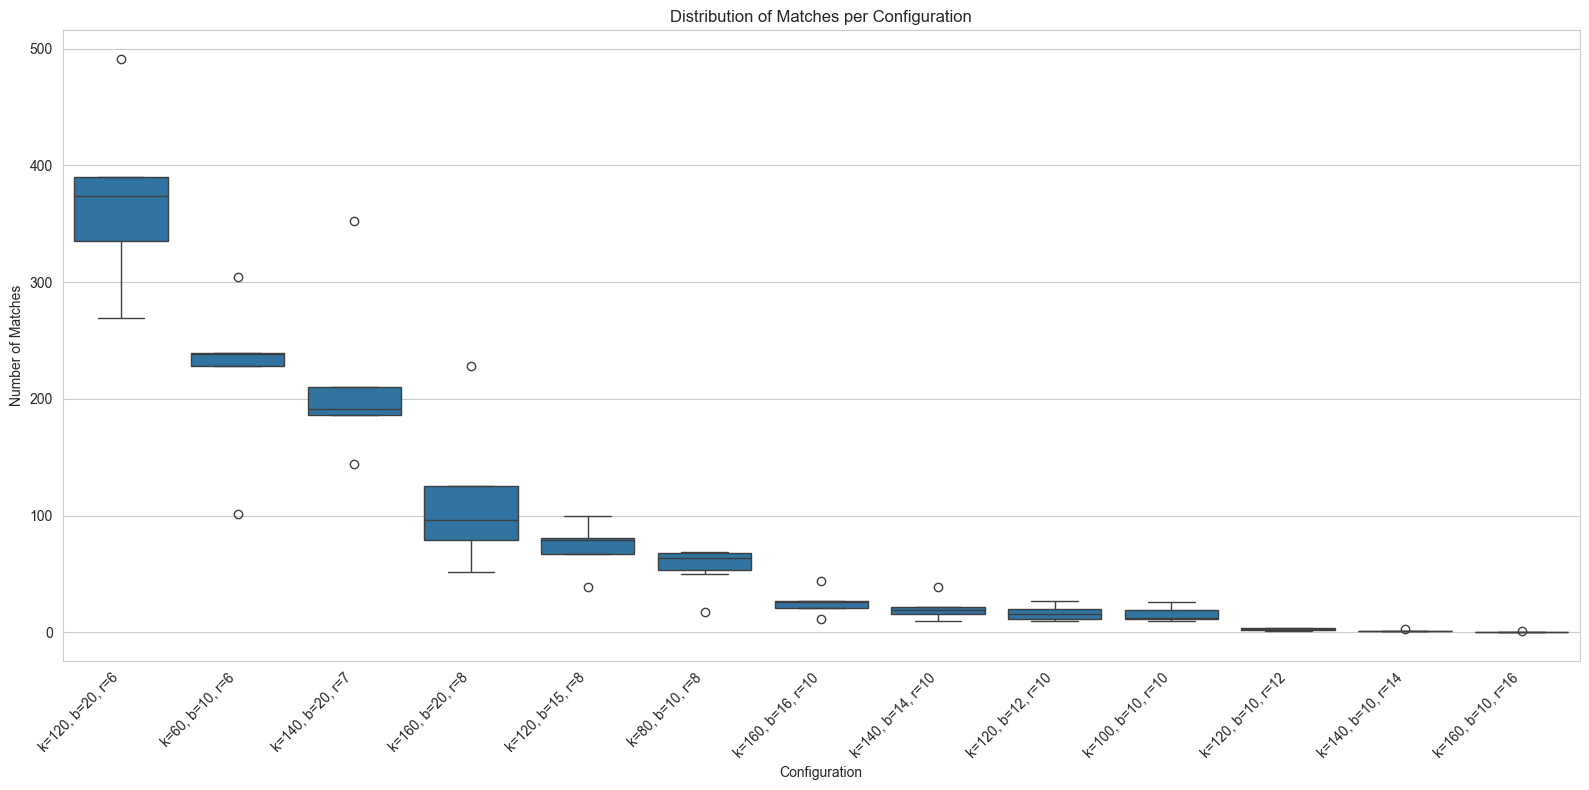

In [17]:
# Create configuration label for plotting
df['config'] = df.apply(lambda x: f"k={int(x['k'])}, b={int(x['bands'])}, r={int(x['rows'])}", axis=1)

# Sort by average matches
config_order = df.groupby('config')['matches'].mean().sort_values(ascending=False).index

plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x='config', y='matches', order=config_order)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Configuration')
plt.ylabel('Number of Matches')
plt.title('Distribution of Matches per Configuration')
plt.tight_layout()
plt.show()

## 3. Ablation: Fixed bands=20, Varying k

In [5]:
# Filter for bands = 20
ablation_k = df[df['bands'] == 20].groupby('k').agg({
    'matches': ['mean', 'std'],
    'time': ['mean', 'std'],
    'seed': 'count'
}).round(2)

ablation_k.columns = ['avg_matches', 'std_matches', 'avg_time', 'std_time', 'num_runs']
ablation_k = ablation_k.reset_index().sort_values('k')

print("Ablation: Fixed bands=20, Varying k:")
ablation_k

Ablation: Fixed bands=20, Varying k:


,k,avg_matches,std_matches,avg_time,std_time,num_runs
0,120,370.83,74.34,629.49,135.48,6
1,140,216.60,79.43,241.81,23.65,5
2,160,116.00,67.99,111.65,16.60,5


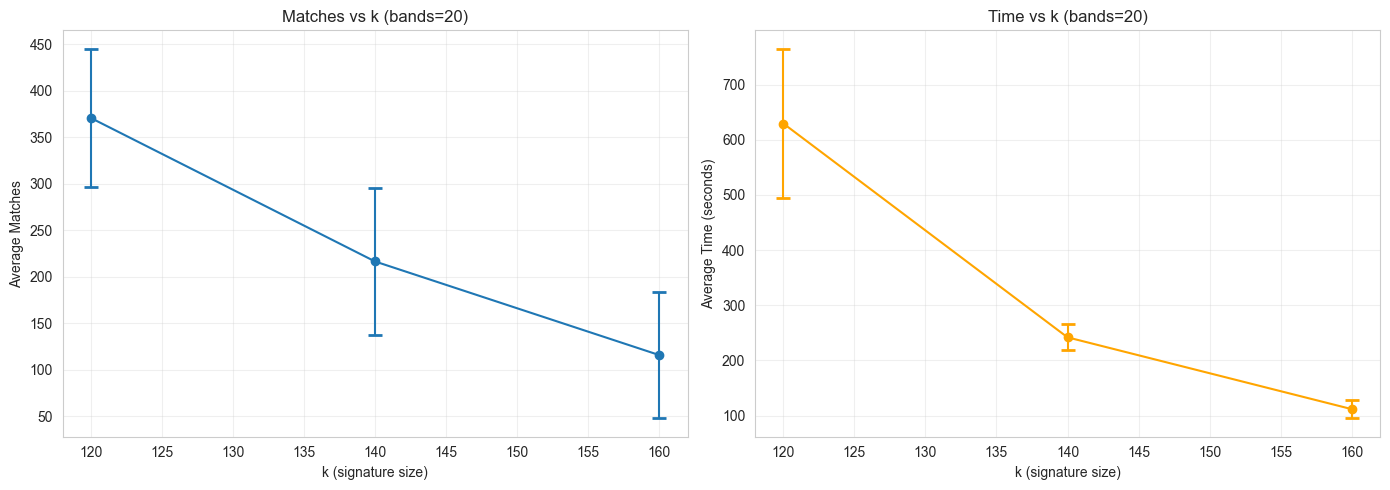

In [ ]:
# Plot ablation for k
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Matches vs k
ax1.errorbar(ablation_k['k'], ablation_k['avg_matches'],
             yerr=ablation_k['std_matches'], marker='o', capsize=5, capthick=2)
ax1.set_xlabel('k (signature size)')
ax1.set_ylabel('Average Matches')
ax1.set_title('Matches vs k (bands=20)')
ax1.grid(True, alpha=0.3)

# Time vs k
ax2.errorbar(ablation_k['k'], ablation_k['avg_time'],
             yerr=ablation_k['std_time'], marker='o', color='orange', capsize=5, capthick=2)
ax2.set_xlabel('k (signature size)')
ax2.set_ylabel('Average Time (seconds)')
ax2.set_title('Time vs k (bands=20)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Ablation: Fixed k=120, Varying bands

In [7]:
# Filter for k = 120
ablation_bands = df[df['k'] == 120].groupby('bands').agg({
    'matches': ['mean', 'std'],
    'time': ['mean', 'std'],
    'seed': 'count'
}).round(2)

ablation_bands.columns = ['avg_matches', 'std_matches', 'avg_time', 'std_time', 'num_runs']
ablation_bands = ablation_bands.reset_index().sort_values('bands')

print("Ablation: Fixed k=120, Varying bands:")
ablation_bands

Ablation: Fixed k=120, Varying bands:


,bands,avg_matches,std_matches,avg_time,std_time,num_runs
0,10,2.80,1.30,50.44,0.63,5
1,12,16.80,6.98,52.88,0.88,5
2,15,73.20,22.48,76.29,9.06,5
3,20,370.83,74.34,629.49,135.48,6


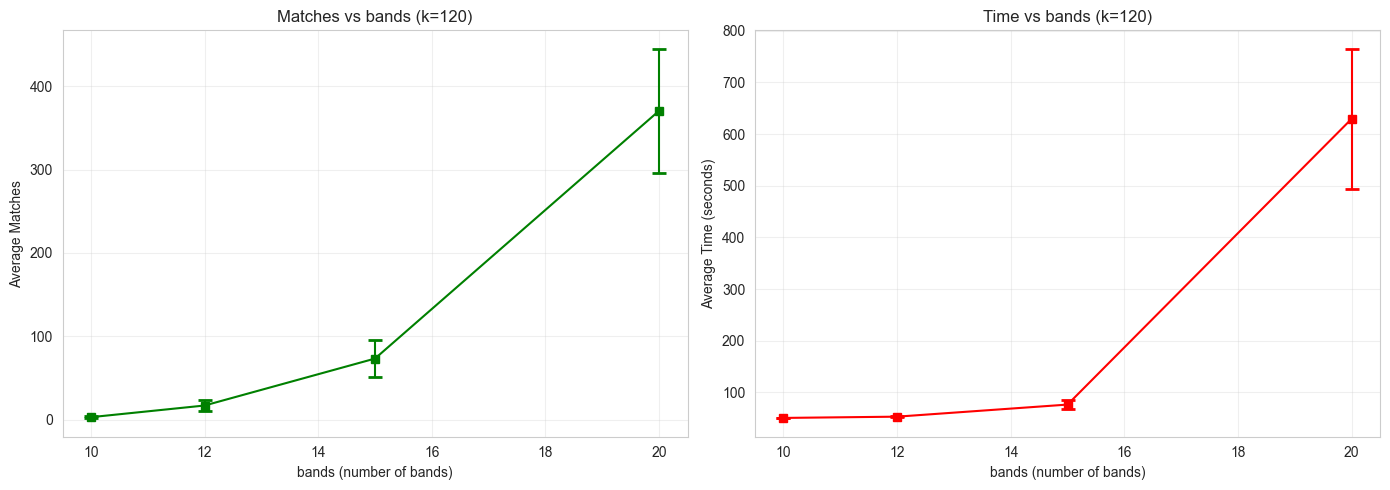

In [ ]:
# Plot ablation for bands
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Matches vs bands
ax1.errorbar(ablation_bands['bands'], ablation_bands['avg_matches'],
             yerr=ablation_bands['std_matches'], marker='s', capsize=5, capthick=2, color='green')
ax1.set_xlabel('bands (number of bands)')
ax1.set_ylabel('Average Matches')
ax1.set_title('Matches vs bands (k=120)')
ax1.grid(True, alpha=0.3)

# Time vs bands
ax2.errorbar(ablation_bands['bands'], ablation_bands['avg_time'],
             yerr=ablation_bands['std_time'], marker='s', color='red', capsize=5, capthick=2)
ax2.set_xlabel('bands (number of bands)')
ax2.set_ylabel('Average Time (seconds)')
ax2.set_title('Time vs bands (k=120)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Grid Plot: Time vs Matches by Configuration

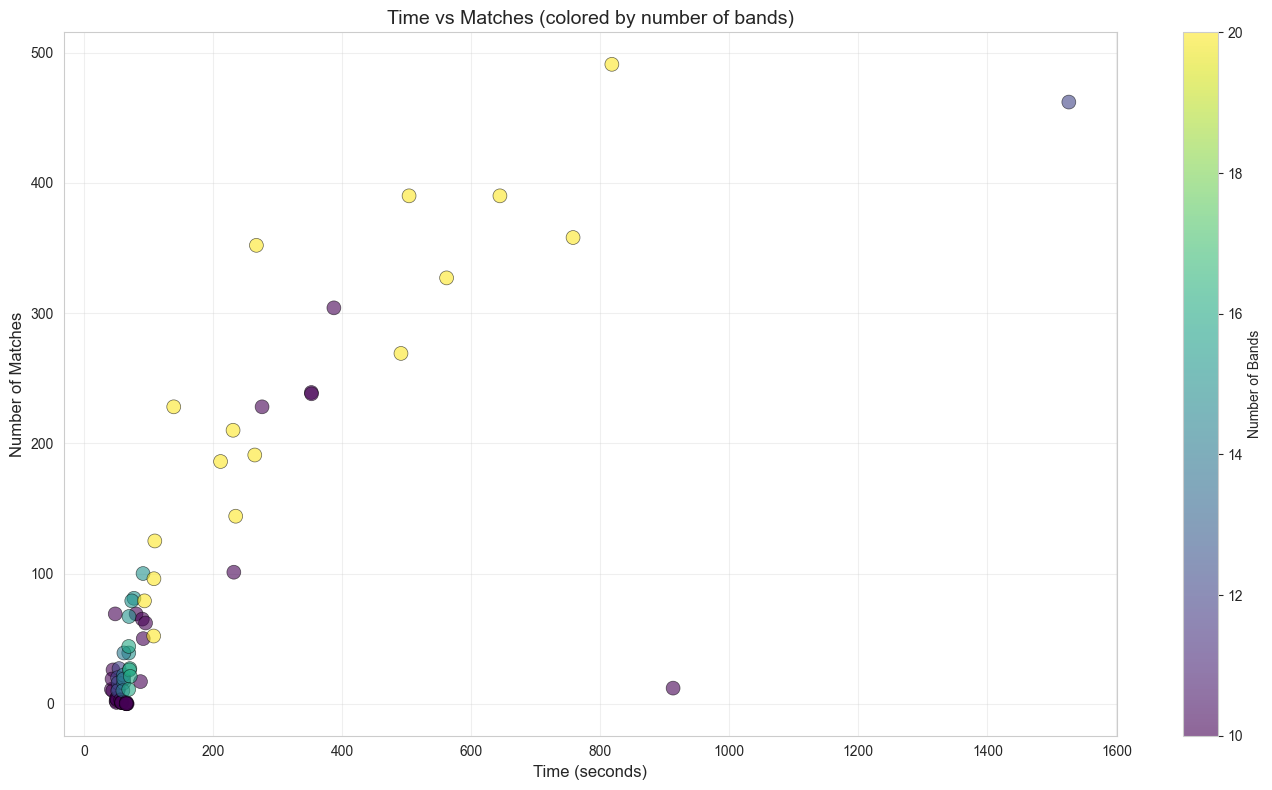

In [ ]:
# Scatter plot with configurations
plt.figure(figsize=(14, 8))

# Color by number of bands
scatter = plt.scatter(df['time'], df['matches'],
                     c=df['bands'], s=100, alpha=0.6,
                     cmap='viridis', edgecolors='black', linewidth=0.5)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.title('Time vs Matches (colored by number of bands)', fontsize=14)
plt.colorbar(scatter, label='Number of Bands')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

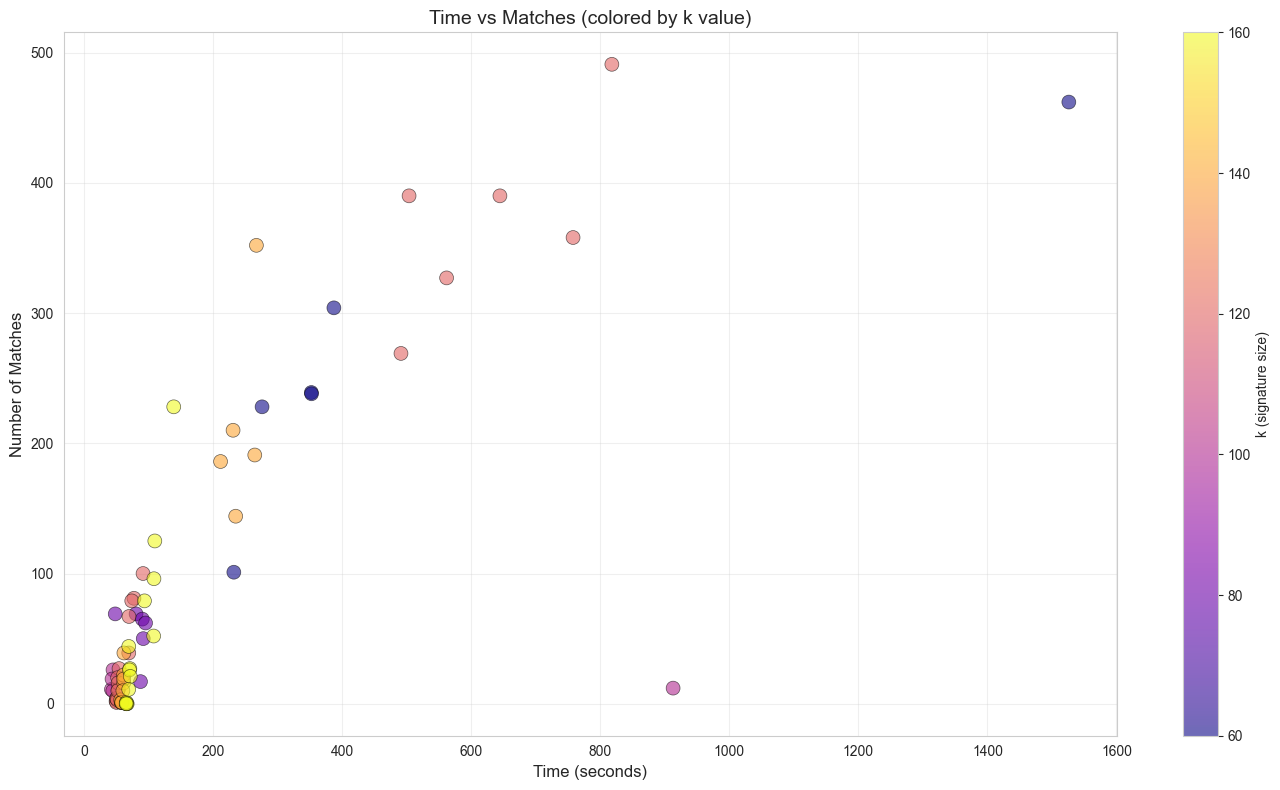

In [ ]:
# Alternative: Grid plot by k values
plt.figure(figsize=(14, 8))

scatter = plt.scatter(df['time'], df['matches'],
                     c=df['k'], s=100, alpha=0.6,
                     cmap='plasma', edgecolors='black', linewidth=0.5)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.title('Time vs Matches (colored by k value)', fontsize=14)
plt.colorbar(scatter, label='k (signature size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Theoretical Time vs Matches: Exponential Fit

Fitted exponential model: time = 77.2581 * exp(0.005538 * matches)
R² = 0.6956


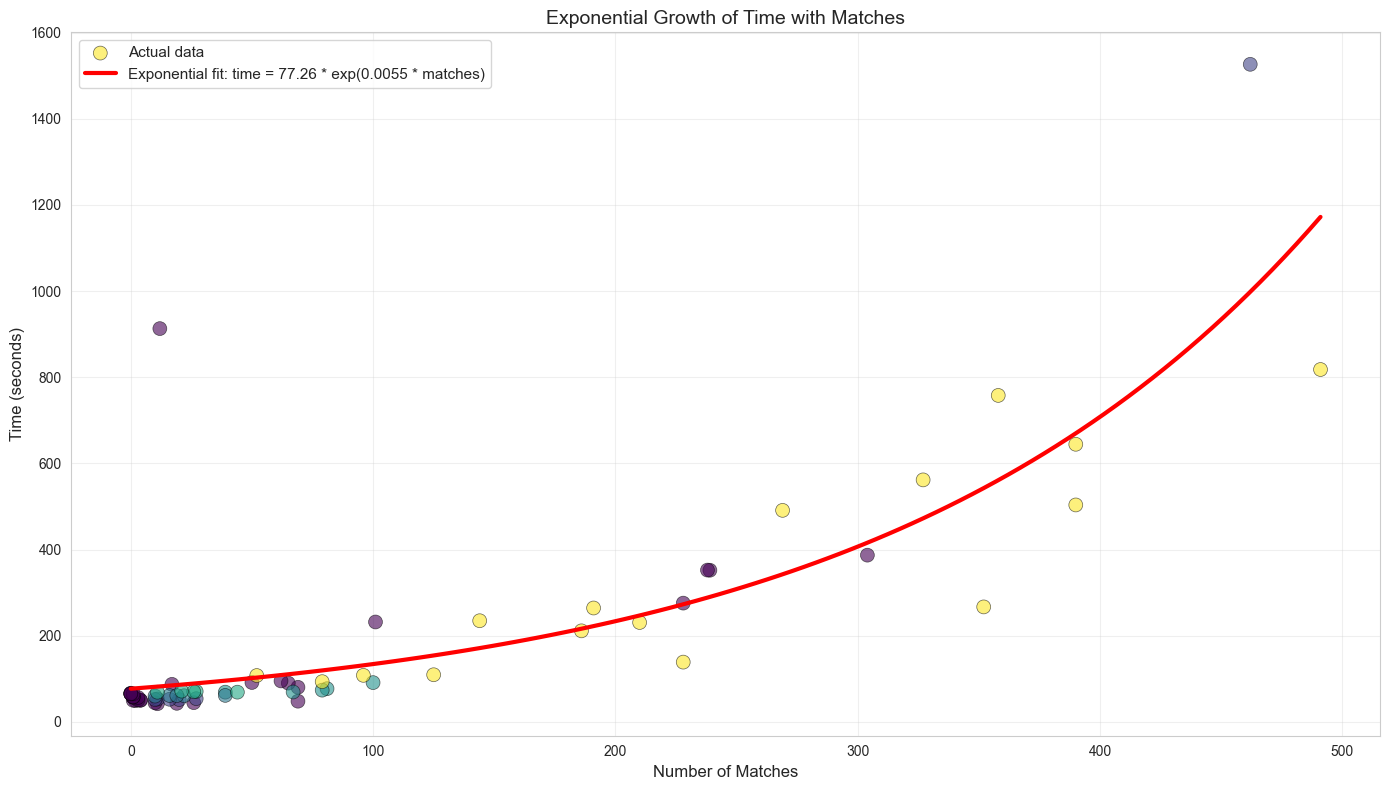

In [13]:
from scipy.optimize import curve_fit

# Define exponential model: time = a * exp(b * matches)
def exponential_model(matches, a, b):
    return a * np.exp(b * matches)

# Fit the model
popt, pcov = curve_fit(exponential_model, df['matches'], df['time'],
                       p0=[1, 0.01], maxfev=10000)

a_fit, b_fit = popt
print(f"Fitted exponential model: time = {a_fit:.4f} * exp({b_fit:.6f} * matches)")
print(f"R² = {1 - np.sum((df['time'] - exponential_model(df['matches'], *popt))**2) / np.sum((df['time'] - df['time'].mean())**2):.4f}")

# Create prediction line
matches_range = np.linspace(df['matches'].min(), df['matches'].max(), 100)
time_pred = exponential_model(matches_range, *popt)

# Plot
plt.figure(figsize=(14, 8))
plt.scatter(df['matches'], df['time'], c=df['bands'], s=100, alpha=0.6,
           cmap='viridis', edgecolors='black', linewidth=0.5, label='Actual data')
plt.plot(matches_range, time_pred, 'r-', linewidth=3,
         label=f'Exponential fit: time = {a_fit:.2f} * exp({b_fit:.4f} * matches)')
plt.xlabel('Number of Matches', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('Exponential Growth of Time with Matches', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Statistics

In [11]:
print("Overall Statistics:")
print(f"Total runs: {len(df)}")
print(f"\nMatches - Mean: {df['matches'].mean():.2f}, Std: {df['matches'].std():.2f}")
print(f"Time - Mean: {df['time'].mean():.2f}s, Std: {df['time'].std():.2f}s")
print(f"\nBest configuration (avg matches): ")
print(config_stats.iloc[0])

Overall Statistics:
Total runs: 68

Matches - Mean: 96.72, Std: 128.30
Time - Mean: 182.72s, Std: 257.30s

Best configuration (avg matches): 
k                60.00
bands            12.00
rows              5.00
threshold         0.50
avg_matches     462.00
std_matches        NaN
avg_time       1526.21
std_time           NaN
num_runs          1.00
Name: 1, dtype: float64
